ame:[Sinya]
Student ID: [023-24-0227]
Section: [G]
GitHub Profile: [https://github.com/sinyaakumarii/lab2_sinya_churn_.git]
Kaggle Profile: [https://www.kaggle.com/sinyakumari1]
Dataset: House Price
Dataset Source: [kaggale]

In [1]:
import pandas as pd
df = pd.read_csv("D:/ML/ML_labs/train.csv")
df.shape
df.info()
df.head()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
import numpy as np
import matplotlib.pyplot as plt
target = 'SalePrice'
num_features = ['GrLivArea', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath']
cat_features = ['Neighborhood', 'HouseStyle', 'ExterQual']
features = num_features + cat_features

X = df[features]
y = df[target]


this is a regression problem because the target variable (SalePrice) is a continuous numeric value, not a discrete category. We will evaluate it using distance-based error metrics like RMSE rather than accuracy or F1-score


In [3]:
# Fill missing numerical values with the mean
X_num = X[num_features].fillna(X[num_features].mean())

# One-hot encode categorical features 
X_cat = pd.get_dummies(X[cat_features], drop_first=True)

# Combine and verify no missing values
X_prepared = pd.concat([X_num, X_cat], axis=1)
print(f"Missing values: {X_prepared.isna().sum().sum()}")
print(f"Are all columns numeric? {np.issubdtype(X_prepared.to_numpy().dtype, np.number)}")

Missing values: 0
Are all columns numeric? False


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X_prepared, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (1168, 39), X_test shape: (292, 39)


In [7]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_test_pred = model.predict(X_test)

# Compare 
comparison_df = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_test_pred})
display(comparison_df.head(10))

,Actual Price,Predicted Price
892,154500,123422.194717
1105,325000,322928.468422
413,115000,117720.237826
522,159000,168712.424398
1036,315500,252392.740850
614,75500,65920.648651
218,311500,230472.685935
1160,146000,151769.164390
649,84500,65198.345727
887,135500,119472.480140


In [8]:
print(f"Intercept (Base Price): {model.intercept_:,.2f}")

coef_df = pd.DataFrame({'Feature': X_prepared.columns, 'Coefficient': model.coef_})
coef_df['Interpretation'] = "Each unit increase changes price by this amount, holding others constant."
display(coef_df.sort_values(by='Coefficient', ascending=False))



Intercept (Base Price): -624,907.01


,Feature,Coefficient,Interpretation
26,Neighborhood_StoneBr,76883.153485,Each unit increase changes price by this amoun...
19,Neighborhood_NoRidge,70568.940652,Each unit increase changes price by this amoun...
20,Neighborhood_NridgHt,65065.560757,Each unit increase changes price by this amoun...
28,Neighborhood_Veenker,61163.354669,Each unit increase changes price by this amoun...
10,Neighborhood_Crawfor,42274.976286,Each unit increase changes price by this amoun...
8,Neighborhood_ClearCr,36747.393815,Each unit increase changes price by this amoun...
27,Neighborhood_Timber,33343.747026,Each unit increase changes price by this amoun...
25,Neighborhood_Somerst,31910.821187,Each unit increase changes price by this amoun...
9,Neighborhood_CollgCr,19242.402002,Each unit increase changes price by this amoun...
34,HouseStyle_SFoyer,18161.234568,Each unit increase changes price by this amoun...


 the intercept represents the baseline house price when all features (area, year built, etc.) are exactly zero. This rarely has a sensible real-world interpretation because a house cannot have 0 square feet or be built in year 0

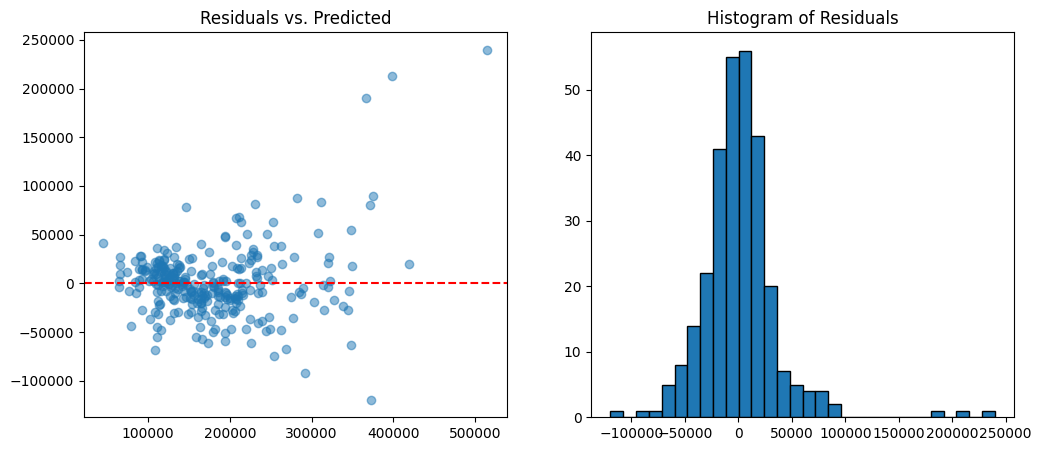

In [9]:
residuals = y_test - y_test_pred

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, edgecolor='black')
plt.title('Histogram of Residuals')
plt.show()

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def calculate_metrics(y_true, y_pred, split_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return pd.DataFrame({'MAE': [mae], 'MSE': [mse], 'RMSE': [rmse], 'R2': [r2]}, index=[split_name])

test_metrics = calculate_metrics(y_test, y_test_pred, 'Test Set')
display(test_metrics)



,MAE,MSE,RMSE,R2
Test Set,23489.459382,1.324840e+09,36398.345546,0.827277


MAE is the average dollar error. RMSE penalizes large errors heavily. R2 explains variance. I would show MAE to a non-technical stakeholder because average dollar error off' is the most intuitive.

In [12]:
# Predict on training set
y_train_pred = model.predict(X_train)
train_metrics = calculate_metrics(y_train, y_train_pred, 'Train Set')

# Compare
comparison_metrics = pd.concat([train_metrics, test_metrics])
display(comparison_metrics)

,MAE,MSE,RMSE,R2
Train Set,22154.630070,1.208968e+09,34770.221129,0.797308
Test Set,23489.459382,1.324840e+09,36398.345546,0.827277


a large gap (where Training R2 is much higher than Test R2) indicates overfitting. If they are close, the model generalizes well to unseen data."

In [14]:
# Load test set
df_test = pd.read_csv('test.csv')

# Apply exact same feature selection
X_sub = df_test[features].copy()

# Prepare numerical and categorical identically
X_sub_num = X_sub[num_features].fillna(X_train[num_features].mean()) # Use train mean
X_sub_cat = pd.get_dummies(X_sub[cat_features], drop_first=True)

# Reindex to ensure dummy columns perfectly match the training set
X_sub_prepared = pd.concat([X_sub_num, X_sub_cat], axis=1)
X_sub_prepared = X_sub_prepared.reindex(columns=X_prepared.columns, fill_value=0)

# Generate predictions
sub_predictions = model.predict(X_sub_prepared)

# Create submission file
submission = pd.DataFrame({'Id': df_test['Id'], 'SalePrice': sub_predictions})
submission.to_csv('submission.csv', index=False)
print("submission.csv successfully generated!")

submission.csv successfully generated!
